# 05. Calculating landcover change over time


## imports


In [1]:
import os
import leafmap
import leafmap.colormaps as cm
import requests
import rasterio as rio
from rasterio.merge import merge
import glob
from rasterio.plot import reshape_as_image

## searching for data


In [2]:
url = "https://earth-search.aws.element84.com/v1/"
collection = "sentinel-2-l2a"
time_range = "2023-08-01/2023-08-31"

In [3]:
# bbox for Aleppo, Syria
bbox = [36.90, 36.00, 37.30, 36.40]

In [4]:
search_gdf = leafmap.stac_search(
    url=url,
    max_items=10,
    collections=[collection],
    bbox=bbox,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 20}},
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    get_gdf=True,
)

In [5]:
search_gdf.columns

Index(['geometry', 'created', 'platform', 'constellation', 'instruments',
       'eo:cloud_cover', 'mgrs:utm_zone', 'mgrs:latitude_band',
       'mgrs:grid_square', 'grid:code', 'view:sun_azimuth',
       'view:sun_elevation', 's2:degraded_msi_data_percentage',
       's2:nodata_pixel_percentage', 's2:saturated_defective_pixel_percentage',
       's2:dark_features_percentage', 's2:cloud_shadow_percentage',
       's2:vegetation_percentage', 's2:not_vegetated_percentage',
       's2:water_percentage', 's2:unclassified_percentage',
       's2:medium_proba_clouds_percentage', 's2:high_proba_clouds_percentage',
       's2:thin_cirrus_percentage', 's2:snow_ice_percentage',
       's2:product_type', 's2:processing_baseline', 's2:product_uri',
       's2:generation_time', 's2:datatake_id', 's2:datatake_type',
       's2:datastrip_id', 's2:granule_id', 's2:reflectance_conversion_factor',
       'datetime', 's2:sequence', 'earthsearch:s3_path',
       'earthsearch:payload_id', 'earthsearch:boa_

In [6]:
search_gdf

,geometry,created,platform,constellation,instruments,eo:cloud_cover,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,grid:code,...,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated,proj:code
0,"POLYGON ((36.75163 37.02527, 36.78007 36.03708...",2023-08-23T22:05:22.717Z,sentinel-2b,sentinel-2,[msi],0.001682,37,S,CA,MGRS-37SCA,...,S2B_OPER_MSI_L2A_TL_2BPS_20230823T113533_A0337...,0.976567,2023-08-23T08:30:00.100000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/da97...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-23T22:05:22.717Z,EPSG:32637
1,"POLYGON ((37.11172 36.13, 36.83614 35.13557, 3...",2023-08-20T18:41:32.774Z,sentinel-2b,sentinel-2,[msi],0.002804,37,S,CV,MGRS-37SCV,...,S2B_OPER_MSI_L2A_TL_2BPS_20230820T112354_A0337...,0.975428,2023-08-20T08:20:19.208000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/6c09...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-20T18:41:32.774Z,EPSG:32637
2,"POLYGON ((37.36857 37.03536, 37.18769 36.39991...",2023-08-20T15:23:11.901Z,sentinel-2b,sentinel-2,[msi],0.003144,37,S,CA,MGRS-37SCA,...,S2B_OPER_MSI_L2A_TL_2BPS_20230820T110437_A0337...,0.975428,2023-08-20T08:20:01.765000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/54de...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-20T15:23:11.901Z,EPSG:32637
3,"POLYGON ((36.77761 36.12427, 36.80482 35.13591...",2023-08-03T16:53:08.632Z,sentinel-2b,sentinel-2,[msi],0.003175,37,S,CV,MGRS-37SCV,...,S2B_OPER_MSI_L2A_TL_2BPS_20230803T112133_A0334...,0.970309,2023-08-03T08:30:14.515000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/dcd8...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-03T16:53:08.632Z,EPSG:32637
4,"POLYGON ((36.77761 36.12427, 36.80482 35.13591...",2023-08-13T17:58:38.550Z,sentinel-2b,sentinel-2,[msi],0.003490,37,S,CV,MGRS-37SCV,...,S2B_OPER_MSI_L2A_TL_2BPS_20230813T114959_A0336...,0.973041,2023-08-13T08:30:15.533000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/d000...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-13T17:58:38.550Z,EPSG:32637
5,"POLYGON ((36.77761 36.12427, 36.80482 35.13591...",2023-08-23T22:38:31.567Z,sentinel-2b,sentinel-2,[msi],0.003915,37,S,CV,MGRS-37SCV,...,S2B_OPER_MSI_L2A_TL_2BPS_20230823T113533_A0337...,0.976567,2023-08-23T08:30:14.256000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/08a9...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-23T22:38:31.567Z,EPSG:32637
6,"POLYGON ((37.11061 36.12998, 36.83449 35.13554...",2023-08-05T17:08:30.847Z,sentinel-2a,sentinel-2,[msi],0.004654,37,S,CV,MGRS-37SCV,...,S2A_OPER_MSI_L2A_TL_2APS_20230805T113557_A0424...,0.970786,2023-08-05T08:20:19.201000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/9d97...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-05T17:08:30.847Z,EPSG:32637
7,"POLYGON ((37.10216 36.12985, 36.82638 35.1354,...",2023-08-25T19:38:34.588Z,sentinel-2a,sentinel-2,[msi],0.006149,37,S,CV,MGRS-37SCV,...,S2A_OPER_MSI_L2A_TL_2APS_20230825T124859_A0426...,0.977357,2023-08-25T08:20:20.258000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/e91f...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-25T19:38:34.588Z,EPSG:32637
8,"POLYGON ((37.367 37.03533, 37.08565 36.04145, ...",2023-08-05T17:03:40.856Z,sentinel-2a,sentinel-2,[msi],0.013748,37,S,CA,MGRS-37SCA,...,S2A_OPER_MSI_L2A_TL_2APS_20230805T113557_A0424...,0.970786,2023-08-05T08:20:04.482000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/d731...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-05T17:03:40.856Z,EPSG:32637
9,"POLYGON ((36.75163 37.02527, 36.78007 36.03708...",2023-08-03T16:57:03.759Z,

## exploring and filtering search results


<Axes: >

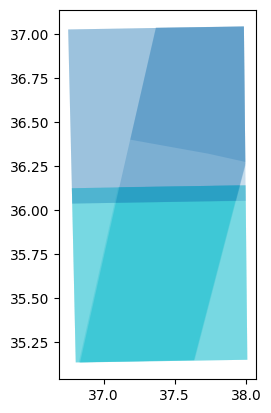

In [7]:
search_gdf.plot("mgrs:grid_square", alpha=0.25)

In [8]:
search_gdf["s2:granule_id"].value_counts()

s2:granule_id
S2B_OPER_MSI_L2A_TL_2BPS_20230823T113533_A033752_T37SCA_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230820T112354_A033709_T37SCV_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230820T110437_A033709_T37SCA_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230803T112133_A033466_T37SCV_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230813T114959_A033609_T37SCV_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230823T113533_A033752_T37SCV_N05.09    1
S2A_OPER_MSI_L2A_TL_2APS_20230805T113557_A042403_T37SCV_N05.09    1
S2A_OPER_MSI_L2A_TL_2APS_20230825T124859_A042689_T37SCV_N05.09    1
S2A_OPER_MSI_L2A_TL_2APS_20230805T113557_A042403_T37SCA_N05.09    1
S2B_OPER_MSI_L2A_TL_2BPS_20230803T112133_A033466_T37SCA_N05.09    1
Name: count, dtype: int64

In [9]:
search_gdf["area"] = search_gdf.geometry.area

In [10]:
search_gdf.sort_values("area", ascending=False, inplace=True)

In [11]:
search_gdf[["area"]]

,area
9,1.205207
0,1.204541
7,1.029399
6,1.021195
1,1.019828
3,0.996175
5,0.991817
4,0.990449
8,0.758291
2,0.502926


In [12]:
search_gdf.drop_duplicates("mgrs:grid_square", inplace=True)

<Axes: >

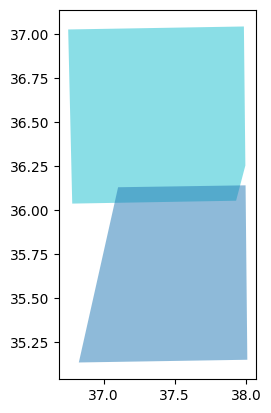

In [13]:
search_gdf.iloc[0:4].plot("s2:granule_id", alpha=0.5)

In [14]:
# # create a query searching for unique datastrip ids based on the above
q = {"s2:granule_id": {"in": search_gdf["s2:granule_id"].iloc[0:4].unique().tolist()}}

search_gdf2 = leafmap.stac_search(
    url=url,
    max_items=4,
    collections=[collection],
    bbox=bbox,
    datetime=time_range,
    query=q,
    get_gdf=True,
)

In [15]:
search_gdf2

,geometry,created,platform,constellation,instruments,eo:cloud_cover,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,grid:code,...,s2:granule_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated,proj:code
0,"POLYGON ((37.10216 36.12985, 36.82638 35.1354,...",2023-08-25T19:38:34.588Z,sentinel-2a,sentinel-2,[msi],0.006149,37,S,CV,MGRS-37SCV,...,S2A_OPER_MSI_L2A_TL_2APS_20230825T124859_A0426...,0.977357,2023-08-25T08:20:20.258000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/e91f...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-25T19:38:34.588Z,EPSG:32637
1,"POLYGON ((36.75163 37.02527, 36.78007 36.03708...",2023-08-03T16:57:03.759Z,sentinel-2b,sentinel-2,[msi],0.014793,37,S,CA,MGRS-37SCA,...,S2B_OPER_MSI_L2A_TL_2BPS_20230803T112133_A0334...,0.970309,2023-08-03T08:30:00.370000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/37/S/C...,roda-sentinel2/workflow-sentinel2-to-stac/d656...,True,{'sentinel2-to-stac': '0.1.1'},2023-08-03T16:57:03.759Z,EPSG:32637


<Axes: >

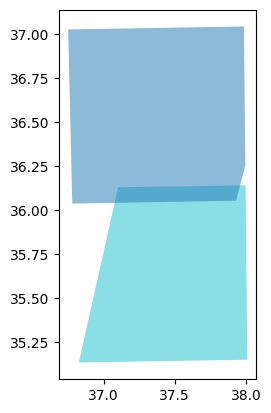

In [16]:
search_gdf2.plot("mgrs:grid_square", alpha=0.5)

### plot to accentuate paved and non-paved divide


In [17]:
search_gdf2_list = leafmap.stac_search(
    url=url,
    max_items=4,
    collections=[collection],
    bbox=bbox,
    datetime=time_range,
    query=q,
    get_links=True,
)

In [18]:
m = leafmap.Map()

for layer in search_gdf2_list:
    m.add_stac_layer(layer, bands=["nir", "red", "green"], name=layer.split("/")[-1])
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

### download files for analysis


In [19]:
def get_raster_band_urls(item: str, bands: list | None = None):
    available_bands = leafmap.stac_bands(item)
    stac = requests.get(item).json()
    band_urls = {
        x: stac["assets"][x]["href"]
        for x in available_bands
        if stac["assets"][x]["href"].startswith("http")
    }

    # if bands, only return bands in list
    if bands:
        band_urls = {x: band_urls[x] for x in bands if x in band_urls}

    return band_urls


def download_stac_layers(layers, out_dir, bands=None):
    for layer in layers:
        band_urls = get_raster_band_urls(layer, bands)
        for band, url in band_urls.items():
            print(url)
            out_file = f"{out_dir}/{layer.split('/')[-1]}_{band}.tif"
            leafmap.download_file(url, out_file, overwrite=False)


def get_stac_crs(item):
    stac = requests.get(item).json()
    return stac["properties"]["proj:epsg"]

In [20]:
stac_crs = get_stac_crs(search_gdf2_list[0])

In [22]:
stac_out_dir = "../Data/stac/aleppo"
os.makedirs(stac_out_dir, exist_ok=True)

download_stac_layers(
    search_gdf2_list,
    stac_out_dir,
)

https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CV/2023/8/S2A_37SCV_20230825_0_L2A/AOT.tif
../Data/stac/aleppo/S2A_37SCV_20230825_0_L2A_aot.tif already exists. Skip downloading. Set overwrite=True to overwrite.
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CV/2023/8/S2A_37SCV_20230825_0_L2A/B02.tif
../Data/stac/aleppo/S2A_37SCV_20230825_0_L2A_blue.tif already exists. Skip downloading. Set overwrite=True to overwrite.
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CV/2023/8/S2A_37SCV_20230825_0_L2A/B01.tif
../Data/stac/aleppo/S2A_37SCV_20230825_0_L2A_coastal.tif already exists. Skip downloading. Set overwrite=True to overwrite.
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CV/2023/8/S2A_37SCV_20230825_0_L2A/B03.tif
../Data/stac/aleppo/S2A_37SCV_20230825_0_L2A_green.tif already exists. Skip downloading. Set overwrite=True to overwrite.
https://sentinel-cogs.s3.us-west-2.amazon

Downloading...
From: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/B04.tif
To: /Users/khaledalanjery/Library/CloudStorage/GoogleDrive-khaled@khaledalanjery.com/My Drive/Design Independent Research and Experimentation/DIRE Projects/Aeolian/Aeolian General/Aeolian Github/aeolian-project-repo/Data/stac/aleppo/S2B_37SCA_20230803_0_L2A_red.tif
100%|██████████| 222M/222M [00:48<00:00, 4.54MB/s] 


https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/B05.tif


Downloading...
From: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/B05.tif
To: /Users/khaledalanjery/Library/CloudStorage/GoogleDrive-khaled@khaledalanjery.com/My Drive/Design Independent Research and Experimentation/DIRE Projects/Aeolian/Aeolian General/Aeolian Github/aeolian-project-repo/Data/stac/aleppo/S2B_37SCA_20230803_0_L2A_rededge1.tif
100%|██████████| 61.1M/61.1M [00:10<00:00, 5.84MB/s]


https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/B06.tif


...

Downloading...
From: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/B12.tif
To: /Users/khaledalanjery/Library/CloudStorage/GoogleDrive-khaled@khaledalanjery.com/My Drive/Design Independent Research and Experimentation/DIRE Projects/Aeolian/Aeolian General/Aeolian Github/aeolian-project-repo/Data/stac/aleppo/S2B_37SCA_20230803_0_L2A_swir22.tif
100%|██████████| 60.0M/60.0M [00:16<00:00, 3.70MB/s]


https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/TCI.tif


Downloading...
From: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/TCI.tif
To: /Users/khaledalanjery/Library/CloudStorage/GoogleDrive-khaled@khaledalanjery.com/My Drive/Design Independent Research and Experimentation/DIRE Projects/Aeolian/Aeolian General/Aeolian Github/aeolian-project-repo/Data/stac/aleppo/S2B_37SCA_20230803_0_L2A_visual.tif
100%|██████████| 336M/336M [01:05<00:00, 5.14MB/s] 


https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/WVP.tif


Downloading...
From: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/S/CA/2023/8/S2B_37SCA_20230803_0_L2A/WVP.tif
To: /Users/khaledalanjery/Library/CloudStorage/GoogleDrive-khaled@khaledalanjery.com/My Drive/Design Independent Research and Experimentation/DIRE Projects/Aeolian/Aeolian General/Aeolian Github/aeolian-project-repo/Data/stac/aleppo/S2B_37SCA_20230803_0_L2A_wvp.tif
100%|██████████| 94.7M/94.7M [00:20<00:00, 4.70MB/s]


In [23]:
# mosaic files based on band name


def mosaic_by_band(
    dir,
    bands: list = [
        "red",
        "blue",
        "green",
        "nir",
        "coastal",
        "nir08",
        "nir09",
        "rededge1",
        "rededge2",
        "rededge3",
        "scl",
        "swir16",
        "swir22",
    ],
    crs: str = None,
):
    mosaics = {}
    for band in bands:
        files = glob.glob(f"{dir}/*{band}.tif")

        out_file = f"{dir}/mosaic_{band}_.tif"
        raster_data = [rio.open(f) for f in files]

        mosaic, out_trans = merge(raster_data)
        out_meta = raster_data[0].meta.copy()
        out_meta.update(
            {
                "driver": "GTiff",
                "height": mosaic.shape[1],
                "width": mosaic.shape[2],
                "transform": out_trans,
                "crs": f"epsg:{crs}",
            }
        )

        with rio.open(out_file, "w", **out_meta) as dest:
            dest.write(mosaic)

        mosaics[band] = out_file

    return mosaics

In [24]:
mosaic_bands_all = mosaic_by_band(stac_out_dir, crs=stac_crs)

In [25]:
mosaic_bands_all

{'red': '../Data/stac/aleppo/mosaic_red_.tif',
 'blue': '../Data/stac/aleppo/mosaic_blue_.tif',
 'green': '../Data/stac/aleppo/mosaic_green_.tif',
 'nir': '../Data/stac/aleppo/mosaic_nir_.tif',
 'coastal': '../Data/stac/aleppo/mosaic_coastal_.tif',
 'nir08': '../Data/stac/aleppo/mosaic_nir08_.tif',
 'nir09': '../Data/stac/aleppo/mosaic_nir09_.tif',
 'rededge1': '../Data/stac/aleppo/mosaic_rededge1_.tif',
 'rededge2': '../Data/stac/aleppo/mosaic_rededge2_.tif',
 'rededge3': '../Data/stac/aleppo/mosaic_rededge3_.tif',
 'scl': '../Data/stac/aleppo/mosaic_scl_.tif',
 'swir16': '../Data/stac/aleppo/mosaic_swir16_.tif',
 'swir22': '../Data/stac/aleppo/mosaic_swir22_.tif'}

In [26]:
nir = rio.open(mosaic_bands_all["nir"]).read(1).astype("float32")
red = rio.open(mosaic_bands_all["red"]).read(1).astype("float32")

### calculate NDVI


In [39]:
ndvi = (nir - red) / (nir + red)

In [40]:
import numpy as np

In [41]:
# fill nan with -2, outside of the range but not so far outside
ndvi[np.isnan(ndvi)] = -1.1

In [42]:
ndvi

array([[ 0.2565142 ,  0.270362  ,  0.22258414, ...,  0.0989489 ,
         0.11058545,  0.12009656],
       [ 0.2052356 ,  0.23085222,  0.20746888, ...,  0.1243625 ,
         0.10526316,  0.12047832],
       [ 0.18214105,  0.16317992,  0.17237799, ...,  0.1257622 ,
         0.12507936,  0.12142039],
       ...,
       [-1.1       , -1.1       , -1.1       , ...,  0.1122058 ,
         0.12682508,  0.12105565],
       [-1.1       , -1.1       , -1.1       , ...,  0.12689173,
         0.13331413,  0.11963882],
       [-1.1       , -1.1       , -1.1       , ...,  0.12731351,
         0.13699032,  0.13891502]], shape=(20982, 10980), dtype=float32)

In [43]:
ndvi_mult = ndvi * 10  # to be able to visualize more easily

In [44]:
ndvi_mult

array([[  2.565142  ,   2.70362   ,   2.2258415 , ...,   0.98948896,
          1.1058545 ,   1.2009655 ],
       [  2.052356  ,   2.3085222 ,   2.074689  , ...,   1.2436249 ,
          1.0526316 ,   1.2047832 ],
       [  1.8214105 ,   1.6317992 ,   1.7237799 , ...,   1.257622  ,
          1.2507937 ,   1.214204  ],
       ...,
       [-11.        , -11.        , -11.        , ...,   1.122058  ,
          1.2682508 ,   1.2105565 ],
       [-11.        , -11.        , -11.        , ...,   1.2689173 ,
          1.3331413 ,   1.1963882 ],
       [-11.        , -11.        , -11.        , ...,   1.2731351 ,
          1.3699032 ,   1.3891501 ]], shape=(20982, 10980), dtype=float32)

In [45]:
ndvi_image = leafmap.array_to_image(ndvi, source=mosaic_bands_all["nir"])

In [34]:
ndvi_multi_image = leafmap.array_to_image(ndvi_mult, source=mosaic_bands_all["nir"])

In [57]:
m = leafmap.Map()
m.add_raster(ndvi_multi_image, layer_name="NDVI", vmin=-10, vmax=10, cmap="PiYG")
m

Map(center=[36.0886245, 37.3806705], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

(array([1.1100000e+02, 8.7500000e+02, 2.8400000e+02, 4.2700000e+02,
        5.0900000e+02, 4.6300000e+02, 3.8500000e+02, 4.1200000e+02,
        5.1900000e+02, 5.9100000e+02, 8.7500000e+02, 9.3300000e+02,
        1.0540000e+03, 1.4130000e+03, 1.2700000e+03, 1.2980000e+03,
        1.3680000e+03, 1.2450000e+03, 1.3260000e+03, 1.2530000e+03,
        1.5930000e+03, 1.5490000e+03, 1.7980000e+03, 2.2690000e+03,
        2.8630000e+03, 4.0750000e+03, 4.8710000e+03, 5.4240000e+03,
        5.9740000e+03, 6.8160000e+03, 7.7630000e+03, 8.3270000e+03,
        9.2570000e+03, 1.0405000e+04, 1.1826000e+04, 1.5400000e+04,
        2.3871000e+04, 4.0991000e+04, 5.9652000e+04, 6.8832000e+04,
        6.7167000e+04, 6.8433000e+04, 7.5983000e+04, 8.0105000e+04,
        7.2388000e+04, 6.8966000e+04, 6.8727000e+04, 7.9479000e+04,
        1.3583200e+05, 2.3437500e+05, 5.4796800e+05, 1.7116510e+06,
        2.8960900e+06, 2.3076114e+07, 7.1065244e+07, 4.4001069e+07,
        2.2917896e+07, 1.2895936e+07, 7.9666600e

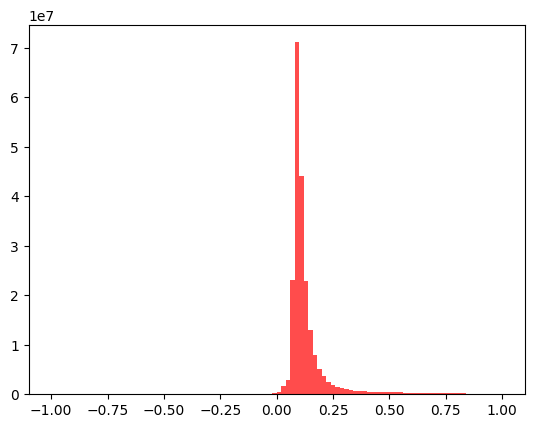

In [51]:
# get histogram of ndvi image values

import matplotlib.pyplot as plt

plt.hist(ndvi[ndvi != -1.1].ravel(), bins=100, color="red", alpha=0.7)

In [52]:
def categorize_np_array(array):

    cat_array = np.zeros(array.shape)
    cat_array[array < 1] = 5
    cat_array[array < 0.8] = 4
    cat_array[array < 0.6] = 3
    cat_array[array < 0.4] = 2
    cat_array[array < 0.2] = 1

    return cat_array

In [53]:
cat_ndvi = categorize_np_array(ndvi)

In [54]:
cat_ndvi

array([[2., 2., 2., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(20982, 10980))

In [55]:
ndvi_image_cat = leafmap.array_to_image(cat_ndvi, source=mosaic_bands_all["nir"])

In [72]:
m = leafmap.Map()
m.add_raster(
    ndvi_image_cat, layer_name="NDVI", vmin=1, vmax=5, cmap="Set1", draw_control=False
)
m.add_colormap(
    "Set1",
    label="ndvi",
    width=8.0,
    height=0.4,
    orientation="horizontal",
    vmin=1,
    vmax=5,
)

m

Map(center=[36.0886245, 37.3806705], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

## k-means


In [58]:
def resample_raster(in_file, out_file, upscale_factor=0.5):
    with rio.open(in_file) as dataset:

        # resample data to target shape
        data = dataset.read(
            out_shape=(
                dataset.count,
                int(dataset.height * upscale_factor),
                int(dataset.width * upscale_factor),
            ),
            resampling=rio.enums.Resampling.bilinear,
        )

        # scale image transform
        transform = dataset.transform * dataset.transform.scale(
            (dataset.width / data.shape[-1]), (dataset.height / data.shape[-2])
        )

        # update metadata
        meta = dataset.meta.copy()
        meta.update(
            {
                "height": data.shape[1],
                "width": data.shape[2],
                "transform": transform,
            }
        )

        with rio.open(out_file, "w", **meta) as dst:
            dst.write(data)

In [59]:
for band in mosaic_bands_all.keys():
    print(band, rio.open(mosaic_bands_all[band]).read(1).shape)

red (20982, 10980)
blue (20982, 10980)
green (20982, 10980)
nir (20982, 10980)
coastal (3497, 1830)
nir08 (10491, 5490)
nir09 (3497, 1830)
rededge1 (10491, 5490)
rededge2 (10491, 5490)
rededge3 (10491, 5490)
scl (10491, 5490)
swir16 (10491, 5490)
swir22 (10491, 5490)


In [61]:
# set resampling ratio for each band- note that some are higher resolution than others and need a different scaling factor
bands_to_resample = {
    "red": 0.25,
    "blue": 0.25,
    "green": 0.25,
    "nir": 0.25,
    "nir08": 0.5,
    "rededge1": 0.5,
    "rededge2": 0.5,
    "rededge3": 0.5,
    "scl": 0.5,
    "swir16": 0.5,
    "swir22": 0.5,
}

In [62]:
# resample the bands so they are all smaller and uniform
for band, ratio in bands_to_resample.items():
    resample_raster(
        mosaic_bands_all[band], f"{stac_out_dir}/upscaled_{band}.tif", ratio
    )
    mosaic_bands_all[f"{band}"] = f"{stac_out_dir}/upscaled_{band}.tif"

In [63]:
mosaic_bands_all

{'red': '../Data/stac/aleppo/upscaled_red.tif',
 'blue': '../Data/stac/aleppo/upscaled_blue.tif',
 'green': '../Data/stac/aleppo/upscaled_green.tif',
 'nir': '../Data/stac/aleppo/upscaled_nir.tif',
 'coastal': '../Data/stac/aleppo/mosaic_coastal_.tif',
 'nir08': '../Data/stac/aleppo/upscaled_nir08.tif',
 'nir09': '../Data/stac/aleppo/mosaic_nir09_.tif',
 'rededge1': '../Data/stac/aleppo/upscaled_rededge1.tif',
 'rededge2': '../Data/stac/aleppo/upscaled_rededge2.tif',
 'rededge3': '../Data/stac/aleppo/upscaled_rededge3.tif',
 'scl': '../Data/stac/aleppo/upscaled_scl.tif',
 'swir16': '../Data/stac/aleppo/upscaled_swir16.tif',
 'swir22': '../Data/stac/aleppo/upscaled_swir22.tif'}

In [64]:
# create a new dict with all bands excpct coastal
mosaic_bands_all_no_coastal = {
    k: v for k, v in mosaic_bands_all.items() if k not in ["coastal", "nir09"]
}

In [65]:
mosaic_bands_all_no_coastal

{'red': '../Data/stac/aleppo/upscaled_red.tif',
 'blue': '../Data/stac/aleppo/upscaled_blue.tif',
 'green': '../Data/stac/aleppo/upscaled_green.tif',
 'nir': '../Data/stac/aleppo/upscaled_nir.tif',
 'nir08': '../Data/stac/aleppo/upscaled_nir08.tif',
 'rededge1': '../Data/stac/aleppo/upscaled_rededge1.tif',
 'rededge2': '../Data/stac/aleppo/upscaled_rededge2.tif',
 'rededge3': '../Data/stac/aleppo/upscaled_rededge3.tif',
 'scl': '../Data/stac/aleppo/upscaled_scl.tif',
 'swir16': '../Data/stac/aleppo/upscaled_swir16.tif',
 'swir22': '../Data/stac/aleppo/upscaled_swir22.tif'}

In [66]:
for band in mosaic_bands_all_no_coastal.keys():
    print(band, rio.open(mosaic_bands_all_no_coastal[band]).read(1).shape)

mosaic_bands_all_no_coastal = np.stack(
    [
        rio.open(mosaic_bands_all_no_coastal[band]).read(1)
        for band in mosaic_bands_all_no_coastal.keys()
    ],
    axis=-1,
)

red (5245, 2745)
blue (5245, 2745)
green (5245, 2745)
nir (5245, 2745)
nir08 (5245, 2745)
rededge1 (5245, 2745)
rededge2 (5245, 2745)
rededge3 (5245, 2745)
scl (5245, 2745)
swir16 (5245, 2745)
swir22 (5245, 2745)


In [67]:
reshaped_img = reshape_as_image(mosaic_bands_all_no_coastal)

In [68]:
reshaped_img.shape

(2745, 11, 5245)

In [69]:
mosaic_bands_all_no_coastal.shape

(5245, 2745, 11)

In [70]:
from sklearn.cluster import KMeans

rows, cols, bands = mosaic_bands_all_no_coastal.shape

k = 10  # num of clusters

kmeans_predictions = KMeans(n_clusters=k, random_state=0).fit(
    mosaic_bands_all_no_coastal.reshape(rows * cols, bands)
)

kmeans_predictions_2d = kmeans_predictions.labels_.reshape(rows, cols)

In [71]:
# plot prediction results

m = leafmap.Map()
m.add_raster(
    leafmap.array_to_image(kmeans_predictions_2d, source=mosaic_bands_all["red"]),
    layer_name="KMeans",
    colormap="Set1",
    draw_control=False,
)

# add a legend
m.add_colormap(
    "Set1",
    label="KMeans",
    width=8.0,
    height=0.4,
    orientation="horizontal",
    vmin=0,
    vmax=9,
)

m

Map(center=[36.0886245, 37.3806705], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…